# AI-ML Assignment

## End-to-End Render Deployment Project

**Name:** Rathlavath Karthik

**Registration Number:** 23BCE11601

**Application Number:** IN26010749

**Batch Number:** 2(B)

# Task 1: Data Collection and Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

import pickle

In [3]:
from google.colab import files

uploaded = files.upload()

Saving StudentsPerformance.csv to StudentsPerformance.csv


In [4]:
df = pd.read_csv("StudentsPerformance.csv")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.describe(include="all")

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
count,1000,1000,1000,1000,1000,1000.00000,1000.000000,1000.000000
unique,2,5,6,2,2,NaN,NaN,NaN
top,female,group C,some college,standard,none,NaN,NaN,NaN
freq,518,319,226,645,642,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,66.08900,69.169000,68.054000
std,NaN,NaN,NaN,NaN,NaN,15.16308,14.600192,15.195657
min,NaN,NaN,NaN,NaN,NaN,0.00000,17.000000,10.000000
25%,NaN,NaN,NaN,NaN,NaN,57.00000,59.000000,57.750000
50%,NaN,NaN,NaN,NaN,NaN,66.00000,70.000000,69.000000
75%,NaN,NaN,NaN,NaN,NaN,77.00000,79.000000,79.000000


In [7]:
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


In [8]:
print("Columns in Dataset")

print(df.columns)

Columns in Dataset
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


# Task 2: Data Preprocessing

In [9]:
X = df.drop("math score", axis=1)
y = df["math score"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1000, 7)
Target Shape: (1000,)


In [10]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['reading score', 'writing score'], dtype='object')

Categorical Features:
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object')


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (800, 7)
Testing Samples: (200, 7)


In [13]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

In [14]:
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [15]:
y_pred = model.predict(X_test)

print("Prediction Completed!")

Prediction Completed!


# Task 3: Model Evaluation

In [16]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("---------------------------")
print("Mean Absolute Error :", mae)
print("Mean Squared Error  :", mse)
print("Root Mean Squared Error :", rmse)
print("R2 Score :", r2)

Model Performance
---------------------------
Mean Absolute Error : 4.214763142474849
Mean Squared Error  : 29.095169866715473
Root Mean Squared Error : 5.393993869732841
R2 Score : 0.8804332983749565


In [17]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
521,91,76.387970
737,53,58.885970
740,80,76.990265
660,74,76.851804
411,84,87.627378
678,81,79.014024
626,69,64.654609
513,54,53.007919
859,87,74.184710
136,51,49.213538


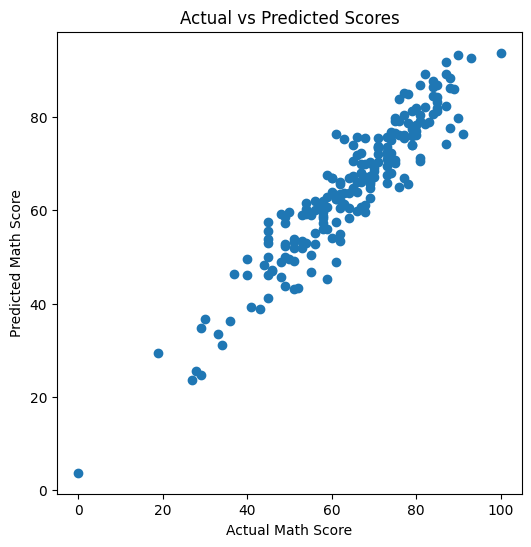

In [18]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted Scores")

plt.show()

In [19]:
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model Saved Successfully!")

Model Saved Successfully!


In [20]:
import os

print(os.listdir())

['.config', 'model.pkl', 'StudentsPerformance.csv', 'sample_data']


# Task 4: Flask Application for Deployment

In [21]:
app_code = '''
from flask import Flask, render_template, request
import pickle
import pandas as pd

app = Flask(__name__)

model = pickle.load(open("model.pkl", "rb"))

@app.route("/")
def home():
    return render_template("index.html")

@app.route("/predict", methods=["POST"])
def predict():

    data = pd.DataFrame({
        "gender":[request.form["gender"]],
        "race/ethnicity":[request.form["race"]],
        "parental level of education":[request.form["education"]],
        "lunch":[request.form["lunch"]],
        "test preparation course":[request.form["course"]],
        "reading score":[int(request.form["reading"])],
        "writing score":[int(request.form["writing"])]
    })

    prediction = model.predict(data)[0]

    return render_template(
        "index.html",
        prediction_text=f"Predicted Math Score: {prediction:.2f}"
    )

if __name__ == "__main__":
    app.run(debug=True)
'''

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py Created Successfully!")

app.py Created Successfully!


In [22]:
requirements = """
flask
pandas
numpy
scikit-learn
gunicorn
"""

with open("requirements.txt","w") as f:
    f.write(requirements)

print("requirements.txt Created!")

requirements.txt Created!


In [23]:
render_yaml = """
services:
- type: web
  name: student-performance-app
  env: python
  buildCommand: pip install -r requirements.txt
  startCommand: gunicorn app:app
"""

with open("render.yaml","w") as f:
    f.write(render_yaml)

print("render.yaml Created!")

render.yaml Created!


In [24]:
import os

os.makedirs("templates", exist_ok=True)

html = """
<!DOCTYPE html>
<html>
<head>
<title>Student Performance Predictor</title>
</head>

<body>

<h2>Student Performance Prediction</h2>

<form action="/predict" method="post">

Gender:
<input name="gender"><br><br>

Race:
<input name="race"><br><br>

Parental Education:
<input name="education"><br><br>

Lunch:
<input name="lunch"><br><br>

Preparation Course:
<input name="course"><br><br>

Reading Score:
<input name="reading" type="number"><br><br>

Writing Score:
<input name="writing" type="number"><br><br>

<input type="submit" value="Predict">

</form>

<h3>{{ prediction_text }}</h3>

</body>
</html>
"""

with open("templates/index.html","w") as f:
    f.write(html)

print("index.html Created!")

index.html Created!


## Observations

1. The Linear Regression model was able to predict students' mathematics scores based on demographic and academic features with good accuracy.

2. The preprocessing pipeline, including One-Hot Encoding for categorical variables and feature scaling where applicable, ensured that the model could effectively process different types of input data.

3. Saving the trained model as `model.pkl` and integrating it with a Flask application makes the prediction system reusable and suitable for deployment on the Render cloud platform.

# Task 5: Conclusion

This project successfully developed an end-to-end machine learning application for predicting student mathematics scores. The dataset was preprocessed, categorical variables were encoded, and a Linear Regression model was trained and evaluated. The trained model was saved using Pickle and integrated into a Flask web application. Additional deployment files such as `requirements.txt`, `render.yaml`, and an HTML interface were created to support deployment on the Render cloud platform. This project demonstrates the complete machine learning workflow from data preprocessing and model training to web application development and cloud deployment.